In [1]:
import pandas as pd

train_df = pd.read_parquet('../data/train.parquet')
test_df = pd.read_parquet('../data/test.parquet')
feature_cols = [c for c in train_df.columns if c not in ['visit', 'treatment_flag', 'spend']]

X_train, y_train, t_train = train_df[feature_cols], train_df['visit'], train_df['treatment_flag']
X_test = test_df[feature_cols]

print(X_train.shape, X_test.shape)

(29885, 11) (12808, 11)


In [2]:
from sklift.models import TwoModels
from xgboost import XGBClassifier

treatment_model = XGBClassifier(random_state=42, eval_metric='logloss')
control_model = XGBClassifier(random_state=42, eval_metric='logloss')
t_learner = TwoModels(treatment_model, control_model, method='vanilla')
t_learner = t_learner.fit(X_train, y_train, t_train)

In [3]:
uplift_t = t_learner.predict(X_test)
print(uplift_t[:10])

[ 0.13896438 -0.00617614  0.03755265  0.1058911  -0.01376386  0.00685973
  0.12691623  0.00916289 -0.1025127   0.04387084]


Mean uplift:   0.0496
Min uplift:    -0.6368
Max uplift:    0.7848
% negative:    30.15%


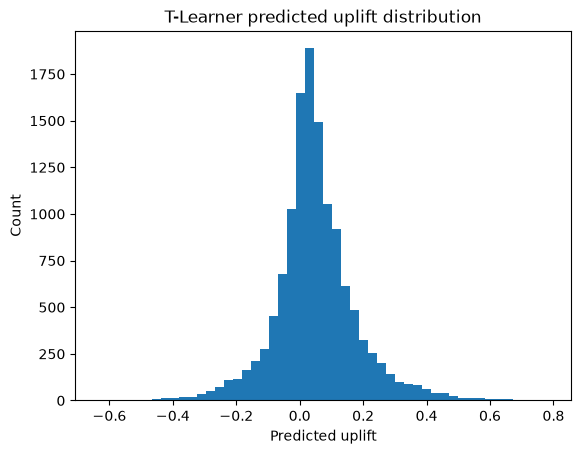

In [4]:
import matplotlib.pyplot as plt

print(f"Mean uplift:   {uplift_t.mean():.4f}")
print(f"Min uplift:    {uplift_t.min():.4f}")
print(f"Max uplift:    {uplift_t.max():.4f}")
print(f"% negative:    {(uplift_t < 0).mean():.2%}")

plt.hist(uplift_t, bins=50)
plt.xlabel('Predicted uplift')
plt.ylabel('Count')
plt.title('T-Learner predicted uplift distribution')
plt.show()

In [5]:
import joblib
joblib.dump(t_learner, '../models/t_learner.pkl')
joblib.dump(treatment_model, '../models/t_learner_treatment_arm.pkl')
joblib.dump(control_model, '../models/t_learner_control_arm.pkl')

['../models/t_learner_control_arm.pkl']

**Sanity check.** Mean predicted uplift (0.0496) tracks observed 4.52pp lift (from 03_ab_test) closely, confirming the model is pointed in the right direction. The spread is wide, though — min −0.64, max 0.78, with 30% of predictions negative — and that should not be read as 30% of customers having genuinely negative uplift. Every subgroup tested in 05_subgroup_heterogeneity (newbie, channel, recency tier) showed a positive mean effect, so a predicted uplift this extreme for any single customer is almost certainly dominated by estimation noise; the T-Learner fits two fully independent models, and subtracting two noisy predictions compounds their errors rather than cancelling them.